In [8]:
import pandas as pd
data = pd.read_csv("bhisma_data.csv")
# all_convergent_cols = [
#     "cortisol",
#     "cpas",
#     "bisq",
#     "ses",
#     "fci",
#     "phq9.score",
#     "mors.invasion",
#     "mors.warmth",
#     "cprs.closeness",
#     "cprs.conflict",
#     "anthro.waz",
#     "anthro.haz",
#     "anthro.wfl",
#     "anthro.hcz",
#     "pmp.daz",
#     "maternal.edu",
#     "paternal.edu",
#     "maternal.muac",
#     "rbs.bin.risk",
#     "pci.int",
# ]
convergent_cols = [
    "cpas",
    "bisq",
    "ses",
    "fci",
    "phq9.score",
    "mors.invasion",
    "mors.warmth",
    "anthro.haz",
    "rbs.bin.risk",
    "pci.int",
]

data = (
    data.rename(columns={"id": "child_ids"})
    .drop_duplicates(subset="child_ids")
    .assign(
        country=lambda df: df["country"].astype(str),
        child_ids=lambda df: df["child_ids"].astype(str) + "-BL",
    )
    [["child_ids", "country"] + convergent_cols]
)

data.head()


,child_ids,country,cpas,bisq,ses,fci,phq9.score,mors.invasion,mors.warmth,anthro.haz,rbs.bin.risk,pci.int
0,IN-0003-BL,IN,0.829047,NaN,-1.100828,0.081612,1.503747,NaN,NaN,1.846310,0.0,NaN
1,IN-0006-BL,IN,0.431599,NaN,0.689174,0.457766,0.050641,NaN,NaN,-0.797824,0.0,NaN
2,IN-0007-BL,IN,0.101850,NaN,-0.745042,1.507111,1.261563,1.776966,0.185820,-1.037449,0.0,NaN
3,IN-0011-BL,IN,1.749237,NaN,-0.429187,0.346437,0.535010,NaN,NaN,NaN,0.0,NaN
4,IN-0012-BL,IN,0.653623,NaN,-0.533899,-2.258632,2.714669,2.333645,-0.338556,0.639923,0.0,NaN


# Convergent Validity: MDAT Age-Adjusted Latent Score

This notebook examines **convergent validity** for the MDAT latent total score (`tot_daz`) — the age-adjusted (GAMLSS-normalised) version of the MDAT IRT–VAE total ability. It tests whether the score is statistically associated with external variables that theory predicts should relate to child development.

## Context

The MDAT total latent score is first age-normalised using GAMLSS (a generalised additive model for location, scale, and shape) to produce a *developmental age z-score* (`tot_daz`). This removes the strong age trend so that residual variation reflects individual differences in development beyond what chronological age explains.

The convergent variables are grouped into:
- **Expected positive**: attachment security, family care, maternal warmth, SES, parent-child interaction, HAZ.
- **Expected negative**: sleep problems (BISQ), maternal depression (PHQ-9), maternal intrusiveness (MORS invasion), risk score (RBS).

## Statistical approach

1. **Pearson r** between `tot_daz` and each convergent variable.
2. **95% confidence intervals** via Fisher z-transformation.
3. **BH-FDR correction** across all tests in each analysis family.
4. Country-stratified analyses (India, Malawi) and a pooled combined analysis.

See the DEEP convergent validity notebook (`convergent_analysis_of_GMDS_predicted_using_DEEP.ipynb`) for a detailed explanation of the statistical methods used here.

In [9]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Load MDAT & merge ────────────────────────────────────────────────────────
mdat = pd.read_csv("total_MDAT_gamlss_results.csv")
mdat = mdat.drop_duplicates(subset="child_ids").assign(child_ids=lambda df: df["child_ids"].astype(str))
assert mdat["child_ids"].shape[0] < 4000, "Unexpectedly many rows in MDAT data after deduplication"
mdat_subscales = ["tot_daz"]

merged = data.merge(mdat[["child_ids"] + mdat_subscales], on="child_ids", how="inner")
merged["country_group"] = merged["child_ids"].str[:2]

india  = merged[merged["country_group"] == "IN"].copy()
malawi = merged[merged["country_group"] == "MW"].copy()

print(f"Children after merge:  {len(merged):>4}  total")
print(f"  India  (IN):         {len(india):>4}")
print(f"  Malawi (MW):         {len(malawi):>4}")

# ── Readable labels ───────────────────────────────────────────────────────────
convergent_labels = {
    "cortisol":       "Cortisol",
    "cpas":           "CPAS (Attachment)",
    "bisq":           "BISQ (Sleep)",
    "ses":            "SES",
    "fci":            "FCI (Family Care)",
    "phq9.score":     "PHQ-9 (Dep. Sx)",
    "mors.invasion":  "MORS Invasion",
    "mors.warmth":    "MORS Warmth",
    "cprs.closeness": "CPRS Closeness",
    "cprs.conflict":  "CPRS Conflict",
    "anthro.waz":     "WAZ (Wt-for-age)",
    "anthro.haz":     "HAZ (Ht-for-age)",
    "anthro.wfl":     "WFL (Wt-for-len.)",
    "anthro.hcz":     "HCZ (Head Circumf.)",
    "pmp.daz":        "PMP DAZ",
    "maternal.edu":   "Maternal Education",
    "paternal.edu":   "Paternal Education",
    "maternal.muac":  "Maternal MUAC",
    "rbs.bin.risk":   "RBS Risk",
    "pci.int":        "PCI Interaction",
}

mdat_labels = {
    "fol":       "Foundations of Learning",
    "langCom":   "Lang. Comp.",
    "eye_hand":  "Eye–Hand",
    "soc_per":   "Soc. Percep.",
    "gross_mot": "Gross Motor",
}

# ── Variable ordering ─────────────────────────────────────────────────────────
anthro_cols = ["anthro.haz"]

pos_convergent_cols = [
    "cpas",           # attachment security → better development
    "fci",            # family care/stimulation → better development
    "mors.warmth",    # maternal warmth → better development
    "ses",            # socioeconomic resources → better development
    "pci.int",        # parent-child interaction quality → better development
    "anthro.haz",
]
neg_convergent_cols = [
    "bisq",           # sleep problems → worse development
    "phq9.score",     # maternal depression → worse development
    "mors.invasion",  # maternal intrusiveness → worse development
    "rbs.bin.risk",   # risk score → worse development
]
convergent_cols_ordered = pos_convergent_cols + neg_convergent_cols
N_POS = len(pos_convergent_cols)

# ── BH-FDR correction ────────────────────────────────────────────────────────
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out   = np.full_like(pvals, np.nan)
    valid = ~np.isnan(pvals)
    idx   = np.where(valid)[0]
    m     = idx.size
    if m == 0:
        return out
    p_sub  = pvals[idx]
    order  = np.argsort(p_sub)
    ranked = np.empty(m); ranked[order] = np.arange(1, m + 1)
    adj    = p_sub * m / ranked
    adj_sorted = adj[order]
    for i in range(m - 2, -1, -1):
        adj_sorted[i] = min(adj_sorted[i], adj_sorted[i + 1])
    adj[order] = adj_sorted
    out[idx] = np.clip(adj, 0, 1)
    return out

# ── Pearson r + 95% CI (Fisher z) + BH-FDR ──────────────────────────────────
def pearson_table(df, row_vars, col_vars, min_n=8):
    r_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    p_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    lo_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    hi_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    n_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    for i, rv in enumerate(row_vars):
        for j, cv in enumerate(col_vars):
            tmp = df[[rv, cv]].dropna()
            n   = len(tmp)
            n_mat[i, j] = n
            if n >= min_n:
                res = stats.pearsonr(tmp[rv], tmp[cv])
                r_mat[i, j]  = res.statistic
                p_mat[i, j]  = res.pvalue
                ci = res.confidence_interval(confidence_level=0.95)
                lo_mat[i, j] = ci.low
                hi_mat[i, j] = ci.high
    pa_flat = bh_fdr(p_mat.flatten())
    pa_mat  = pa_flat.reshape(p_mat.shape)
    kw = dict(index=row_vars, columns=col_vars)
    return (
        pd.DataFrame(r_mat,  **kw), pd.DataFrame(p_mat,  **kw),
        pd.DataFrame(pa_mat, **kw), pd.DataFrame(lo_mat, **kw),
        pd.DataFrame(hi_mat, **kw), pd.DataFrame(n_mat,  **kw),
    )

# ── Significance stars ────────────────────────────────────────────────────────
def stars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    if p < 0.10:   return "·"
    return ""

# ── Formatted table: r* [lo, hi] ─────────────────────────────────────────────
def make_display_table(r_df, pa_df, lo_df, hi_df):
    rows = [convergent_labels.get(r, r) for r in r_df.index]
    cols = [mdat_labels.get(c, c)       for c in r_df.columns]
    out  = pd.DataFrame(index=rows, columns=cols)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            r  = r_df.iloc[i, j];  p  = pa_df.iloc[i, j]
            lo = lo_df.iloc[i, j]; hi = hi_df.iloc[i, j]
            if np.isnan(r):
                out.iloc[i, j] = "—"
            else:
                out.iloc[i, j] = f"{r:+.2f}{stars(p):3} [{lo:+.2f}, {hi:+.2f}]"
    return out

# ── Heatmap — r, CI, and N shown inside cells ────────────────────────────────
def draw_heatmap(r_df, pa_df, lo_df, hi_df, n_df, title, ax, show_separator=True):
    r_plot = r_df.copy().astype(float)
    r_plot.index   = [convergent_labels.get(r, r) for r in r_df.index]
    r_plot.columns = [mdat_labels.get(c, c)       for c in r_df.columns]

    annot = pd.DataFrame("", index=r_plot.index, columns=r_plot.columns)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            val   = r_df.iloc[i, j];  p    = pa_df.iloc[i, j]
            lo    = lo_df.iloc[i, j]; hi   = hi_df.iloc[i, j]
            n_val = n_df.iloc[i, j]
            rl = convergent_labels.get(rv, rv)
            cl = mdat_labels.get(cv, cv)
            if not np.isnan(val):
                s     = stars(p)
                line1 = f"{val:+.2f}{s}"
                line2 = f"[{lo:+.2f},{hi:+.2f}]" if not np.isnan(lo) else ""
                line3 = f"n={int(n_val)}" if not np.isnan(n_val) else ""
                annot.loc[rl, cl] = "\n".join(l for l in [line1, line2, line3] if l)

    sns.heatmap(
        r_plot, ax=ax,
        annot=annot, fmt="",
        center=0, vmin=-1, vmax=1,
        cmap="RdBu_r",
        linewidths=0.5, linecolor="#e0e0e0",
        cbar_kws={"shrink": 0.55, "label": "Pearson r"},
        annot_kws={"size": 10},
    )

    if show_separator:
        n_rows = len(r_df)
        ax.hlines(N_POS, xmin=0, xmax=len(r_df.columns),
                  colors="#111", linewidths=2.5, linestyles="--")
        blend = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
        # ax.text(-0.01, N_POS / 2.0,
        #         "Expected\n(+)", ha="right", va="center",
        #         fontsize=7.5, color="#444", style="italic",
        #         transform=blend, clip_on=False)
        # ax.text(-0.01, N_POS + (n_rows - N_POS) / 2.0,
        #         "Expected\n(−)", ha="right", va="center",
        #         fontsize=7.5, color="#444", style="italic",
        #         transform=blend, clip_on=False)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("MDAT Subscale", fontsize=10, labelpad=6)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)


Children after merge:  1967  total
  India  (IN):          944
  Malawi (MW):         1023


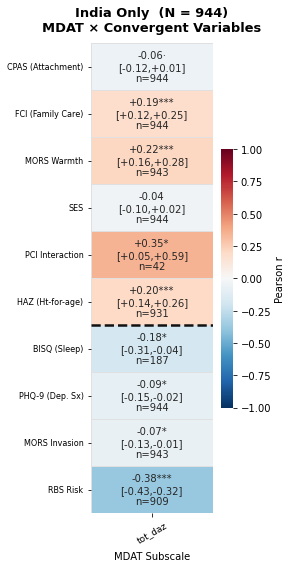


── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,tot_daz
CPAS (Attachment),"-0.06· [-0.12, +0.01]"
FCI (Family Care),"+0.19*** [+0.12, +0.25]"
MORS Warmth,"+0.22*** [+0.16, +0.28]"
SES,"-0.04 [-0.10, +0.02]"
PCI Interaction,"+0.35* [+0.05, +0.59]"
HAZ (Ht-for-age),"+0.20*** [+0.14, +0.26]"
BISQ (Sleep),"-0.18* [-0.31, -0.04]"
PHQ-9 (Dep. Sx),"-0.09* [-0.15, -0.02]"
MORS Invasion,"-0.07* [-0.13, -0.01]"
RBS Risk,"-0.38*** [-0.43, -0.32]"



────────────────────────────────────────────────────────────
  India — Anthropometric Variables
────────────────────────────────────────────────────────────


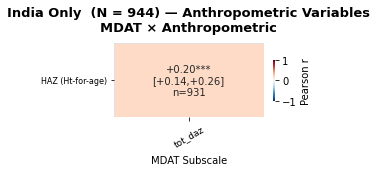


── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,tot_daz
HAZ (Ht-for-age),"+0.20*** [+0.14, +0.26]"


In [10]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 1 — INDIA ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_in, p_in, pa_in, lo_in, hi_in, n_in = pearson_table(india, convergent_cols_ordered, mdat_subscales)

fig, ax = plt.subplots(figsize=(4, 8))
draw_heatmap(r_in, pa_in, lo_in, hi_in, n_in,
             f"India Only  (N = {len(india)})\nMDAT × Convergent Variables", ax)
plt.tight_layout()
# plt.savefig("heatmap_india.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_in, pa_in, lo_in, hi_in))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  India — Anthropometric Variables")
print("─" * 60)
r_in_a, p_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a = pearson_table(india, anthro_cols, mdat_subscales)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a,
             f"India Only  (N = {len(india)}) — Anthropometric Variables\nMDAT × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
# plt.savefig("heatmap_india_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_in_a, pa_in_a, lo_in_a, hi_in_a))


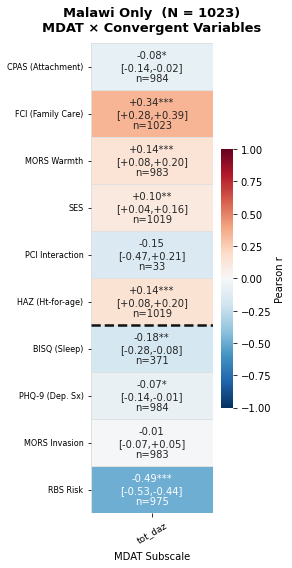


── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,tot_daz
CPAS (Attachment),"-0.08* [-0.14, -0.02]"
FCI (Family Care),"+0.34*** [+0.28, +0.39]"
MORS Warmth,"+0.14*** [+0.08, +0.20]"
SES,"+0.10** [+0.04, +0.16]"
PCI Interaction,"-0.15 [-0.47, +0.21]"
HAZ (Ht-for-age),"+0.14*** [+0.08, +0.20]"
BISQ (Sleep),"-0.18** [-0.28, -0.08]"
PHQ-9 (Dep. Sx),"-0.07* [-0.14, -0.01]"
MORS Invasion,"-0.01 [-0.07, +0.05]"
RBS Risk,"-0.49*** [-0.53, -0.44]"



────────────────────────────────────────────────────────────
  Malawi — Anthropometric Variables
────────────────────────────────────────────────────────────


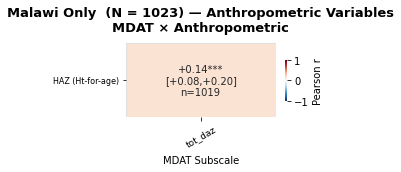


── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,tot_daz
HAZ (Ht-for-age),"+0.14*** [+0.08, +0.20]"


In [11]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 2 — MALAWI ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_mw, p_mw, pa_mw, lo_mw, hi_mw, n_mw = pearson_table(malawi, convergent_cols_ordered, mdat_subscales)

fig, ax = plt.subplots(figsize=(4, 8))
draw_heatmap(r_mw, pa_mw, lo_mw, hi_mw, n_mw,
             f"Malawi Only  (N = {len(malawi)})\nMDAT × Convergent Variables", ax)
plt.tight_layout()
# plt.savefig("heatmap_malawi.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_mw, pa_mw, lo_mw, hi_mw))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  Malawi — Anthropometric Variables")
print("─" * 60)
r_mw_a, p_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a = pearson_table(malawi, anthro_cols, mdat_subscales)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a,
             f"Malawi Only  (N = {len(malawi)}) — Anthropometric Variables\nMDAT × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
# plt.savefig("heatmap_malawi_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a))


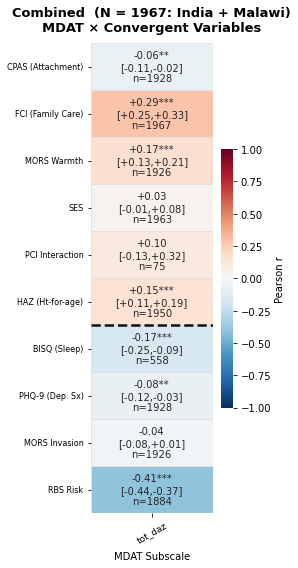


── Combined: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,tot_daz
CPAS (Attachment),"-0.06** [-0.11, -0.02]"
FCI (Family Care),"+0.29*** [+0.25, +0.33]"
MORS Warmth,"+0.17*** [+0.13, +0.21]"
SES,"+0.03 [-0.01, +0.08]"
PCI Interaction,"+0.10 [-0.13, +0.32]"
HAZ (Ht-for-age),"+0.15*** [+0.11, +0.19]"
BISQ (Sleep),"-0.17*** [-0.25, -0.09]"
PHQ-9 (Dep. Sx),"-0.08** [-0.12, -0.03]"
MORS Invasion,"-0.04 [-0.08, +0.01]"
RBS Risk,"-0.41*** [-0.44, -0.37]"



────────────────────────────────────────────────────────────
  Combined — Anthropometric Variables
────────────────────────────────────────────────────────────


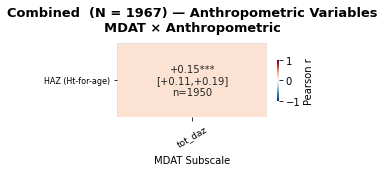


── Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,tot_daz
HAZ (Ht-for-age),"+0.15*** [+0.11, +0.19]"


In [12]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 3 — COMBINED (India + Malawi)
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_all, p_all, pa_all, lo_all, hi_all, n_all = pearson_table(merged, convergent_cols_ordered, mdat_subscales)

fig, ax = plt.subplots(figsize=(4, 8))
draw_heatmap(r_all, pa_all, lo_all, hi_all, n_all,
             f"Combined  (N = {len(merged)}: India + Malawi)\nMDAT × Convergent Variables", ax)
plt.tight_layout()
# plt.savefig("heatmap_combined.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Combined: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_all, pa_all, lo_all, hi_all))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  Combined — Anthropometric Variables")
print("─" * 60)
r_all_a, p_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a = pearson_table(merged, anthro_cols, mdat_subscales)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a,
             f"Combined  (N = {len(merged)}) — Anthropometric Variables\nMDAT × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
# plt.savefig("heatmap_combined_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_all_a, pa_all_a, lo_all_a, hi_all_a))
